In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })
import pandas as pd
import h5py

import jax.numpy as jnp
from jesterTOV.inference.flows.flow import Flow
from jesterTOV.utils import redshift_to_luminosity_distance

events = pd.read_csv('../../eos_inference/wide_ETL/events.dat', sep=" ")

# load EOS
m_eos, r_eos, l_eos = np.loadtxt("../../eos/RMF3_MRL.dat", unpack=True)
mtov = m_eos.max()
n_eos, p_eos = np.loadtxt("../../eos/RMF3_cold_beta_lamb.d", unpack=True, usecols=[1,3])

In [2]:
hyperposterior = dict()
with h5py.File("./cosmo_inference/outdir/results.h5") as f:

    for key in ["H0", "Omega0"]:
        hyperposterior[key] = f["posterior"]["parameters"][key][:]
    hyperposterior['log_prob'] = f["posterior"]["log_prob"][:]



Text(0, 0.5, '$d_L$ [Mpc]')

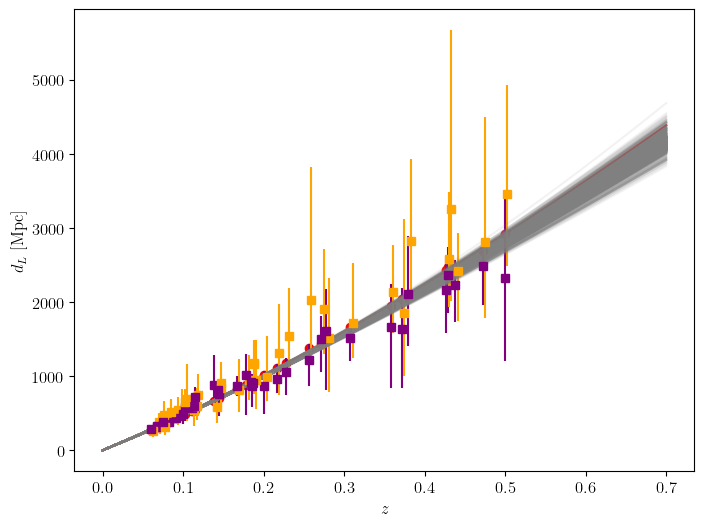

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))

quantiles_gw = np.zeros(events.shape[0])
quantiles_em = np.zeros(events.shape[0])

z_arr = np.linspace(0, 0.7, 100)
dL_arr = redshift_to_luminosity_distance(z_arr)
ax.plot(z_arr, dL_arr, color="red")

for src in range(events.shape[0]):
    ax.scatter(events.loc[src, "redshift_measured"], events.loc[src, "luminosity_distance"], color="red")

    posterior_gw = np.load(f"../../eos_inference/wide_ETL/gw_posteriors/source_{src}/posterior_mm.npz")
    posterior_em = np.load(f"../../eos_inference/wide_ETL/em_posteriors/source_{src}/posterior.npz")
    quantiles_gw[src] = np.mean(events.loc[src, "luminosity_distance"] >= posterior_gw["luminosity_distance"])
    quantiles_em[src] = np.mean(events.loc[src, "luminosity_distance"] >= posterior_em["luminosity_distance"])

    lower_em, median_em, upper_em = np.quantile(posterior_em["luminosity_distance"], [1/events.shape[0], 0.5, 1-1/events.shape[0]])
    ax.errorbar(events.loc[src, "redshift_measured"]+0.003, median_em, ([median_em-lower_em], [upper_em-median_em]), color="orange", fmt="s")

    lower_gw, median_gw, upper_gw = np.quantile(posterior_gw["luminosity_distance"], [1/events.shape[0], 0.5, 1-1/events.shape[0]])
    ax.errorbar(events.loc[src, "redshift_measured"], median_gw, ([median_gw-lower_gw], [upper_gw-median_gw]), color="purple", fmt="s")


    if events.loc[src, "luminosity_distance"] < lower_em or events.loc[src, "luminosity_distance"] > upper_em:
        print("em problematic: ", src)
    if events.loc[src, "luminosity_distance"] < lower_gw or events.loc[src, "luminosity_distance"] > upper_gw:
        print("gw_problematic: ", src)


for j in range(1000):
    z_arr = np.linspace(0, 0.7, 100)
    dL_arr = redshift_to_luminosity_distance(z_arr, H0=hyperposterior["H0"][j], Omega0=hyperposterior["Omega0"][j])
    ax.plot(z_arr, dL_arr, color="grey", alpha=0.1)


ax.set_xlabel("$z$")
ax.set_ylabel("$d_L$ [Mpc]")
#ax.set_yscale("log")


In [4]:
events.loc[[3, 15, 25, 31], ["redshift", "luminosity_distance", "theta_jn"]]

,redshift,luminosity_distance,theta_jn
3,0.201542,1021.213051,2.909036
15,0.309316,1660.529318,0.036613
25,0.186303,935.664227,0.211937
31,0.076397,357.809984,2.110859


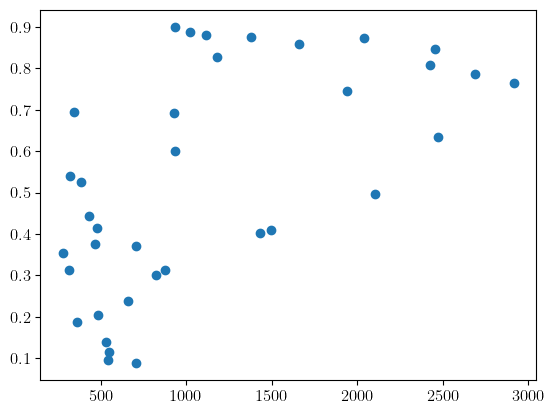

In [6]:
plt.scatter(events["luminosity_distance"], quantiles_gw)


(array([9., 9., 2., 3., 1., 4., 3., 1., 1., 3.]),
 array([0.03912267, 0.111464  , 0.18380533, 0.25614667, 0.328488  ,
        0.40082933, 0.47317067, 0.545512  , 0.61785333, 0.69019467,
        0.762536  ]),
 [<matplotlib.patches.Polygon at 0x7f91ac3762d0>])

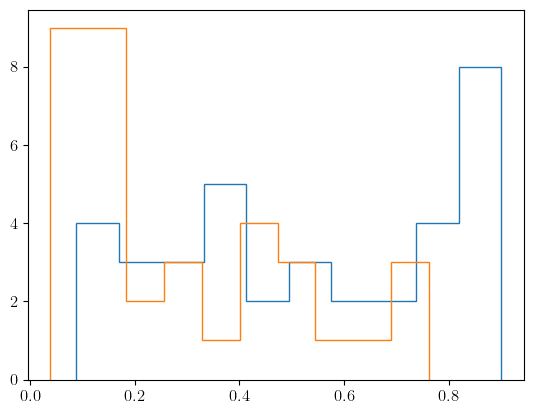

In [7]:

plt.hist(quantiles_gw, histtype="step")
plt.hist(quantiles_em, histtype="step")